In [ ]:
# The budget menu — what a spending cap buys, in instrument units

**Who this is for.** This notebook is written to be readable without a
technical background. Every term of art gets a short explanation, in
parentheses, at its first use. It reuses finished machinery: the required-rate
schedules from `step3_analysis` (t09), the published outlays (t12), and the
delivery verdicts from the `itcfbm` model runs (r01/r03).

**The setting, in brief.** Our study prices what it costs to buy a national
deployment schedule for new nuclear plants. The detection analysis showed
that an observer learns which cost world the program is in only by spending —
many failing worlds have committed most of a spending cap before any alarm
can fire. So this notebook answers the ex-ante design question instead: **for
a decision maker with a firm willingness to pay, what credit does that budget
buy, and what share of cost worlds does it deliver?**

The government declares one support schedule in advance — the reference: the
middle (p50) world's required credit path. The declared percentage can apply
to *realized* cost (a percentage ITC: overruns raise the outlay) or to the
*reference* cost (a fixed-basis credit: a $/kW amount fixed in advance, the
vendor absorbs overruns). **Under a matched budget rule the two forms deliver
the same worlds to within design uncertainty** (shown below), so the menu is
reported once, in both policy units: the average statutory ITC fraction and
the average dollars per kilowatt. The form choice is a risk-allocation
choice — who eats overruns — which this LP cannot price (no risk aversion,
no moral hazard), not a delivery-efficiency choice.

**The budget rule** (the cap is a chosen setting, not a result): the
**hard cap** — the credit's outlay must stay within X in every world. For the
fixed-basis credit the rule binds exactly (its outlay is world-invariant); for
the realized-cost ITC the binding world is its most expensive delivering
world. A quantile variant (outlay within X in at least 95% of worlds — the 5%
mirrors the detection analysis's false-alarm budget) is kept as a sensitivity:
it is vacuous for the fixed basis and relaxes only the ITC, and that
asymmetry — not the instruments — was the entire "ITC lead" in the v2 horse
race (see the version log in `methods.md`).

**Delivery, per world.** A world delivers when the offered credit covers that
world's own required-rate schedule in every build year, with a one-point
cushion (the model runs certify it: one point below the requirement still
over-delivers in 6 of 6 ladders; five points below fails in all — r03).

**Data rules.** Everything is computed offline from stored, checked
artifacts — no new model runs. Gates G0-G5 are registered in `methods.md`,
with the v1→v2→v3 log. The six schedules, smallest to largest: eia, aj,
iaea, mck, cop28, eo. Run on the **playground-env** kernel. Tables are
`s01`-`s04`, figures `k`-numbered (`k01` retired with the v2 horse race;
the menu figure is `k02`).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.insert(0, str(Path.cwd().parent))
import plotstyle as ps
ps.apply()

pd.set_option("display.width", 220)

HERE = Path.cwd()
assert HERE.name == "instrument_comparison", f"run from z-ethan/instrument_comparison/, not {HERE}"
REPO = HERE.parents[1]
EXPORTS = HERE / "exports"
FIGURES = HERE / "figures"
EXPORTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

MC_EXPORTS = REPO / "z-ethan" / "mc" / "exports"
CHECKS3 = REPO / "z-ethan" / "step3_checks" / "exports"
S3ANALYSIS = REPO / "z-ethan" / "step3_analysis" / "exports"
ITCFBM = REPO / "z-ethan" / "itcfbm_analysis" / "exports"

TOL_EXCEED = 0.05  # the quantile variant's exceedance tolerance (chosen setting)
TOL_SHORT = 0.01   # delivery cushion, statutory rate points (r03-certified)

# ---- the MC ensemble --------------------------------------------------------------
Z = np.load(MC_EXPORTS / "mc_perdraw.npz")
META = json.loads(str(Z["meta_json"]))
assert META["n_draws"] == 10000 and META["master_seed"] == 20260715, META
YI = {int(y): i for i, y in enumerate(Z["years"])}

SCHEDULES = ["eia", "aj", "iaea", "mck", "cop28", "eo"]  # ambition order
AB2TOK = {"eia": "eia_aeo_high", "aj": "abou_jaoude", "iaea": "iaea_high",
          "mck": "mckinsey", "cop28": "cop28", "eo": "eo2025"}
TOK2AB = {v: k for k, v in AB2TOK.items()}
NAME2AB = {str(n): TOK2AB[str(t)] for n, t in zip(Z["sched_order"], Z["scen_tokens"])}

reg_smr = pd.read_csv(MC_EXPORTS / "smr100" / "selected_draws.csv")
reg_smr["ab"] = reg_smr["schedule"].map(NAME2AB)
assert len(reg_smr) == 18 and reg_smr["ab"].notna().all()
ANCH = {ab: {} for ab in SCHEDULES}
for _, r in reg_smr.iterrows():
    ANCH[r["ab"]][r["percentile"]] = int(r["draw_index"])

# ---- duals -> program additions; discount rate ------------------------------------
duals3 = pd.read_csv(CHECKS3 / "duals_by_year.csv")
YEARS_RUN = sorted(int(t) for t in duals3["t"].unique())
GAP = {t: (YEARS_RUN[i + 1] - t if i + 1 < len(YEARS_RUN) else 1)
       for i, t in enumerate(YEARS_RUN)}
FLOOR = duals3[duals3["t"] <= 2030].groupby("case")["mandate_MW"].max()
duals3["program_MW"] = (duals3["mandate_MW"]
                        - duals3["case"].map(FLOOR).fillna(0.0)).clip(lower=0.0)
DCASE = {c: g.set_index("t") for c, g in duals3.groupby("case")}

FIN_DIR = REPO / "inputs" / "financials"
sys_fin = pd.read_csv(FIN_DIR / "financials_sys_ATB2024.csv")
infl = pd.read_csv(FIN_DIR / "inflation_default.csv")
sys_fin = sys_fin.merge(infl, on="t", how="left")
sys_fin["d_nom"] = ((1 - sys_fin["debt_fraction"]) * (sys_fin["rroe_nom"] - 1)
                    + sys_fin["debt_fraction"] * (sys_fin["interest_rate_nom"] - 1)
                      * (1 - sys_fin["tax_rate"]) + 1)
sys_fin["d_real"] = sys_fin["d_nom"] / sys_fin["inflation_rate"]
_s = sys_fin.set_index("t")["d_real"].reindex(range(1990, 2051)).ffill()
DR = float(np.mean(_s.loc[np.arange(2010, 2051)].to_numpy(float)))
assert round(DR, 4) == 1.0455, DR
_infl = infl.set_index("t")["inflation_rate"]
D2224 = float(_infl.loc[2023] * _infl.loc[2024])  # 2022$ -> 2024$ price level
assert 1.0 < D2224 < 1.2, D2224

# ---- published tables + gate G0 ---------------------------------------------------
t08 = pd.read_csv(S3ANALYSIS / "t08_rental_transfer.csv")

def anchor_bill(case, T=2050):
    # PV of the subsidy bill through year T, 2024 $B, base year 2026 (t08 exact)
    d = DCASE[case]
    pv = 0.0
    for t in d.index:
        if t < 2026 or d.loc[t, "program_MW"] <= 0:
            continue
        yrs = min(GAP[t], max(0, T - t + 1))
        if yrs <= 0:
            continue
        pv += (d.loc[t, "dual_2024_MWyr"] * d.loc[t, "program_MW"] / 1e9
               * yrs / DR ** (t - 2026))
    return float(pv)

g0_fail = []
for _, r in t08.iterrows():
    if not r["case"].startswith("smr100_") or r["case"].endswith("_eq"):
        continue
    pv = anchor_bill(r["case"], 2050)
    if abs(pv - r["PV_rental_transfer_2024B"]) > 0.051:
        g0_fail.append((r["case"], round(pv, 2), r["PV_rental_transfer_2024B"]))
assert not g0_fail, g0_fail
G0 = True
T08 = t08.set_index("case")
P50BILL = {ab: float(T08.loc[f"smr100_{ab}_p50", "PV_rental_transfer_2024B"])
           for ab in SCHEDULES}
print(f"G0 PASS: t08 reproduced for all smr100 anchors (<=0.051 $B)")
print(f"DR = {DR:.4f}; 2022->2024 factor = {D2224:.4f}")
print("p50 anchor bills (2024 $B):", {k: round(v, 1) for k, v in P50BILL.items()})

# required-rate schedules (headline convention) + published outlays
t09 = pd.read_csv(S3ANALYSIS / "t09_required_itc.csv")
t09r = t09[t09["status"] == "rate"].set_index(["case", "t"])["i_model_headline"]
t12 = pd.read_csv(S3ANALYSIS / "t12_fiscal_comparison.csv").set_index("case")

def rate_of(case, t):
    v = t09r.get((case, t), 0.0)
    return float(v) if np.isfinite(v) else 0.0


G0 PASS: t08 reproduced for all smr100 anchors (<=0.051 $B)
DR = 1.0455; 2022->2024 factor = 1.0712
p50 anchor bills (2024 $B): {'eia': 31.1, 'aj': 32.7, 'iaea': 91.8, 'mck': 116.3, 'cop28': 190.8, 'eo': 331.9}


## S1 — every world gets a required-rate schedule, then two thresholds

Only the 3 anchor worlds per schedule carry model-computed required rates
(t09: the headline rate per build year — the credit sufficient in the
highest-need building region that year). Every other world's rates are
interpolated the stage-2 way: per build year, the three anchor points (that
year's build cost against that year's required rate) are connected with
straight line segments, and a world's rate is read off at its own build
cost, held flat beyond the outer anchors. The stage-2 predict-the-middle
test certifies this family of interpolations to ±20%; that band is carried
through as gate G5.

From the interpolated schedule i_w(t), with the reference i_ref(t) = the p50
world's schedule and the reference costs = the p50 world's build costs:

- **ITC threshold** s\*: the smallest scale s such that s x i_ref(t) covers
  i_w(t) less the one-point cushion in every build year. The ITC's outlay
  scales with the world's own realized costs.
- **Fixed-basis threshold** f\*: the same, but coverage is in dollars per
  kilowatt — f x i_ref(t) x refcost(t) against i_w(t) x owncost(t) — so the
  outlay is the world-invariant reference amount.

At the p50 world both thresholds equal the same number just below 1 (the
calibration point). Worlds that need more than the cushion in a year the
reference prices at zero are **uncoverable** by either instrument (shape
risk, shared; measured share: zero in all six schedules).

**Outlay calibration.** The estimator's outlay arithmetic (rate x national
OCC x additions, block-discounted) reproduces the published t12 ITC outlays
at 0.75-0.86x — the shortfall is the financing multiplier plus the regional
capex heterogeneity that the national-OCC shortcut cannot see. Each
schedule's outlays are therefore calibrated to the published t12 anchors
(gate G3 bounds the residual); world-to-world variation still comes from
each world's own cost path.

In [2]:
ADD, BUILD_TS = {}, {}
IREF, IW, OCCW = {}, {}, {}     # reference schedule; per-world rates; per-world 2024$ costs
SSTAR, FSTAR, COVER = {}, {}, {}
SPW, SPREF, KAPPA, KAP_RES = {}, {}, {}, {}
IBAR, CBAR = {}, {}             # menu unit conversions at scale 1
g1_fail = []

for ab in SCHEDULES:
    d0 = DCASE[f"smr100_{ab}_p05"]
    for p in ["p50", "p95"]:
        assert (DCASE[f"smr100_{ab}_{p}"]["program_MW"].values
                == d0["program_MW"].values).all(), "mandate differs across anchors"
    build_ts = [int(t) for t in d0.index if t >= 2026 and d0.loc[t, "program_MW"] > 0]
    prog = np.array([d0.loc[t, "program_MW"] for t in build_ts])
    add = np.diff(prog, prepend=0.0).clip(min=0.0)
    disc = np.array([DR ** -(t - 2026) for t in build_ts])
    keep = add > 0
    BUILD_TS[ab] = [t for t, k in zip(build_ts, keep) if k]
    ADD[ab] = add[keep]
    disc = disc[keep]

    occ = Z[f"occ_{AB2TOK[ab]}_smr"]
    occ_t = np.stack([occ[:, YI[t]] for t in BUILD_TS[ab]], axis=1)  # 2022 $/kW
    OCCW[ab] = occ_t * D2224                                        # 2024 $/kW
    cases = {p: f"smr100_{ab}_{p}" for p in ["p05", "p50", "p95"]}

    iw = np.empty_like(occ_t)
    for j, t in enumerate(BUILD_TS[ab]):
        xs = np.array([occ[ANCH[ab][p], YI[t]] for p in ["p05", "p50", "p95"]])
        ys = np.array([rate_of(cases[p], t) for p in ["p05", "p50", "p95"]])
        o = np.argsort(xs)
        xs, ys = xs[o], ys[o]
        assert np.all(np.diff(xs) > 0), (ab, t, xs)
        iw[:, j] = np.interp(occ_t[:, j], xs, ys)  # clamps outside the anchors
    IW[ab] = iw
    IREF[ab] = np.array([rate_of(cases["p50"], t) for t in BUILD_TS[ab]])

    # G1a: the interpolation passes through the anchors exactly
    for p in ["p05", "p50", "p95"]:
        w_ = ANCH[ab][p]
        tru = np.array([rate_of(cases[p], t) for t in BUILD_TS[ab]])
        if np.max(np.abs(iw[w_] - tru)) > 1e-9:
            g1_fail.append((ab, p, "anchor rate identity"))

    # thresholds with the one-point cushion; uncoverable where the reference is 0
    need = np.maximum(iw - TOL_SHORT, 0.0)
    ref = IREF[ab][None, :]
    with np.errstate(divide="ignore", invalid="ignore"):
        s_ratio = np.where(need > 0, need / np.where(ref > 0, ref, np.nan), 0.0)
    uncov = np.any((need > 0) & (ref <= 0), axis=1)
    SSTAR[ab] = np.where(uncov, np.inf, np.nanmax(np.where(need > 0, s_ratio, 0.0),
                                                  axis=1, initial=0.0))
    refc = (IREF[ab] * OCCW[ab][ANCH[ab]["p50"]])[None, :]  # reference $/kW credit
    with np.errstate(divide="ignore", invalid="ignore"):
        f_ratio = np.where(need > 0,
                           need * OCCW[ab] / np.where(refc > 0, refc, np.nan), 0.0)
    FSTAR[ab] = np.where(uncov, np.inf, np.nanmax(np.where(need > 0, f_ratio, 0.0),
                                                  axis=1, initial=0.0))
    COVER[ab] = ~uncov

    # outlays: own-schedule anchors calibrate the level to the published t12
    raw_own = {}
    for p in ["p05", "p50", "p95"]:
        w_ = ANCH[ab][p]
        i_own = np.array([rate_of(cases[p], t) for t in BUILD_TS[ab]])
        raw_own[p] = float(np.sum(i_own * OCCW[ab][w_] * ADD[ab] * disc) * 1000 / 1e9)
    pub = {p: float(t12.loc[cases[p], "PV_ITC_outlay_2024B"]) for p in ["p05", "p50", "p95"]}
    KAPPA[ab] = float(np.mean([pub[p] / raw_own[p] for p in ["p05", "p50", "p95"]]))
    KAP_RES[ab] = max(abs(KAPPA[ab] * raw_own[p] / pub[p] - 1) for p in ["p05", "p50", "p95"])

    spw_raw = np.sum(IREF[ab][None, :] * OCCW[ab] * ADD[ab][None, :] * disc[None, :],
                     axis=1) * 1000 / 1e9
    SPW[ab] = KAPPA[ab] * spw_raw
    SPREF[ab] = float(SPW[ab][ANCH[ab]["p50"]])

    # menu unit conversions at scale 1 (reference world):
    # IBAR = outlay-weighted average statutory rate of the reference schedule;
    # CBAR = additions-weighted average reference credit, 2024 $/kW
    occ_ref = OCCW[ab][ANCH[ab]["p50"]]
    wgt_val = occ_ref * ADD[ab] * disc
    IBAR[ab] = float(np.sum(IREF[ab] * wgt_val) / wgt_val.sum())
    wgt_add = ADD[ab] * disc
    CBAR[ab] = float(np.sum(IREF[ab] * occ_ref * wgt_add) / wgt_add.sum())

    # G1b: at the p50 anchor both thresholds equal (iref - cushion)/iref's max
    w50 = ANCH[ab]["p50"]
    exp50 = float(np.max(np.maximum(IREF[ab] - TOL_SHORT, 0.0)
                         / np.where(IREF[ab] > 0, IREF[ab], np.inf)))
    if not (abs(SSTAR[ab][w50] - exp50) < 1e-9 and abs(FSTAR[ab][w50] - exp50) < 1e-9):
        g1_fail.append((ab, "p50", "calibration-point identity"))

G1 = not g1_fail
assert G1, g1_fail
print("G1 PASS: interpolation exact at all 18 anchors; p50 thresholds sit at the "
      "calibration point")
rows = []
for ab in SCHEDULES:
    fin = np.isfinite(SSTAR[ab])
    rows.append(dict(schedule=ab, kappa=round(KAPPA[ab], 3),
                     kappa_resid=round(KAP_RES[ab], 3),
                     spref_2024B=round(SPREF[ab], 1),
                     p50bill_2024B=round(P50BILL[ab], 1),
                     spref_over_bill=round(SPREF[ab] / P50BILL[ab], 2),
                     ibar_ref=round(IBAR[ab], 3),
                     cbar_ref_kW=round(CBAR[ab], 0),
                     share_uncoverable=round(1 - COVER[ab].mean(), 4),
                     sstar_p50=round(float(np.median(SSTAR[ab][fin])), 3),
                     sstar_p95=round(float(np.percentile(SSTAR[ab][fin], 95)), 3)))
cal = pd.DataFrame(rows)
print(cal.to_string(index=False))
G3 = bool((cal["kappa_resid"] <= 0.07).all())
assert G3, cal[["schedule", "kappa_resid"]].to_string()
print("G3 PASS: post-calibration outlay residual <= 7% at all 18 anchors")

s01 = pd.concat([pd.DataFrame({
    "schedule": ab, "world": np.arange(len(SSTAR[ab])),
    "coverable": COVER[ab],
    "sstar": np.round(SSTAR[ab], 4), "fstar": np.round(FSTAR[ab], 4),
    "itc_outlay_at_s1_2024B": np.round(SPW[ab], 2),
}) for ab in SCHEDULES], ignore_index=True)
s01.to_csv(EXPORTS / "s01_per_world_thresholds.csv", index=False)
print(f"\ns01: {len(s01)} rows")


G1 PASS: interpolation exact at all 18 anchors; p50 thresholds sit at the calibration point
schedule  kappa  kappa_resid  spref_2024B  p50bill_2024B  spref_over_bill  ibar_ref  cbar_ref_kW  share_uncoverable  sstar_p50  sstar_p95
     eia  1.259        0.052         57.5           31.1             1.85     0.661       4278.0                0.0      1.000      1.427
      aj  1.263        0.052         85.3           32.7             2.61     0.645       4301.0                0.0      1.099      1.515
    iaea  1.212        0.025        184.0           91.8             2.00     0.709       3924.0                0.0      1.053      1.343
     mck  1.206        0.036        227.6          116.3             1.96     0.674       3760.0                0.0      1.043      1.363
   cop28  1.191        0.018        418.1          190.8             2.19     0.740       3650.0                0.0      1.039      1.323
      eo  1.197        0.004        626.3          331.9             1.89     0.


s01: 60000 rows


## S2 — the external cross-checks (G2)

The thresholds must agree with the model runs that already exist:

- The reference schedules used here (t09 headline rates) must equal the rate
  schedules the `itcfbm` feed-back runs actually fed (r01 `i_head`), exactly,
  for the three ladder schedules (aj, mck, eo).
- The r03 verdicts must support the one-point cushion: the deepest delivering
  rung is one point below the headline (m01) and the shallowest failing rung
  five points below (m05), in every ladder.

In [3]:
r01 = pd.read_csv(ITCFBM / "r01_rate_ladder.csv")
r03 = pd.read_csv(ITCFBM / "r03_minimality_verdicts.csv")
LADDER_WORLDS = ["aj", "mck", "eo"]
assert set(LADDER_WORLDS) <= set(r01["world"].unique()), r01["world"].unique()

heads = r01.drop_duplicates(["world", "t"]).set_index(["world", "t"])["i_head"]
g2_fail = []
for ab in LADDER_WORLDS:
    case = f"smr100_{ab}_p50"
    ts = sorted(set(heads.loc[ab].index) & set(BUILD_TS[ab]))
    assert ts, (ab, "no shared years")
    diff = max(abs(float(heads.loc[(ab, t)]) - rate_of(case, t)) for t in ts)
    if diff > 1e-6:
        g2_fail.append((ab, "i_head mismatch", round(diff, 6)))
if not (set(r03["deepest_delivering_rung"]) == {"m01"}
        and set(r03["shallowest_failing_rung"]) == {"m05"}):
    g2_fail.append(("r03", "bracket changed",
                    sorted(r03["deepest_delivering_rung"].unique())))
G2 = not g2_fail
assert G2, g2_fail
print("G2 PASS: t09 reference schedules equal the fed r01 headline rates "
      "(max diff <= 1e-6) for aj/mck/eo; r03 bracket = (headline-5, headline-1] "
      f"in all {len(r03)} ladders - the one-point cushion is the certified edge")


G2 PASS: t09 reference schedules equal the fed r01 headline rates (max diff <= 1e-6) for aj/mck/eo; r03 bracket = (headline-5, headline-1] in all 6 ladders - the one-point cushion is the certified edge


## S3 — the budget menu, and the matched-rule equivalence behind it

For each cap X on the grid (0.45-2.50 × the schedule's p50 published bill):

- **The menu setting**: the largest credit scale the cap affords under the
  hard rule. For the fixed-basis credit this binds exactly — scale =
  X / (reference outlay) — and is reported in both policy units: the
  outlay-weighted **average statutory ITC fraction** (scale × the reference
  schedule's average rate) and the additions-weighted **average dollars per
  kilowatt** (scale × the reference schedule's average credit).
- **The delivered share**: the share of worlds whose requirement that
  setting covers. Reported for both instrument forms —
  `share_flat` (fixed basis) and `share_itc_hard` (realized-cost ITC, its
  scale capped by its most expensive delivering world) — and their gap is
  the **matched-rule equivalence check**: if the two forms were really
  different delivery technologies, these columns would separate.
- **The quantile sensitivity**: the ITC re-sized under the 95%-of-worlds
  rule (`share_itc_95`). The relaxation is vacuous for the fixed basis, so
  any gap between `share_itc_95` and `share_itc_hard` is the value of the
  tolerance clause, not of the instrument.

The ±20% band (gate G5) rescales every world's requirement by 0.8x and 1.2x
(the stage-2 interpolation certificate) and recomputes the menu shares.

In [4]:
MULT = np.round(np.arange(0.45, 2.51, 0.05), 2)
SGRID = np.round(np.arange(0.0, 6.0001, 0.005), 4)

def thresholds(ab, scale):
    # rescale the interpolated need (not the declared reference) by `scale`
    need = np.maximum(IW[ab] * scale - TOL_SHORT, 0.0)
    ref = IREF[ab][None, :]
    uncov = np.any((need > 0) & (ref <= 0), axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        s_r = np.where(need > 0, need / np.where(ref > 0, ref, np.nan), 0.0)
        refc = (IREF[ab] * OCCW[ab][ANCH[ab]["p50"]])[None, :]
        f_r = np.where(need > 0,
                       need * OCCW[ab] / np.where(refc > 0, refc, np.nan), 0.0)
    sstar = np.where(uncov, np.inf, np.nanmax(np.where(need > 0, s_r, 0.0),
                                              axis=1, initial=0.0))
    fstar = np.where(uncov, np.inf, np.nanmax(np.where(need > 0, f_r, 0.0),
                                              axis=1, initial=0.0))
    return sstar, fstar

def sweep(ab, scale):
    sstar, fstar = (SSTAR[ab], FSTAR[ab]) if scale == 1.0 else thresholds(ab, scale)
    sp = SPW[ab]
    n = len(sp)
    X = MULT * P50BILL[ab]
    order = np.argsort(sstar)
    ss, sps = sstar[order], sp[order]
    run_max = np.maximum.accumulate(sps)  # worst delivering-world outlay at scale 1

    # fixed basis: binds exactly at the cap
    f_max = X / SPREF[ab]
    share_flat = np.array([(fstar <= f).mean() for f in f_max])

    # realized-cost ITC, hard rule: outlay <= X in every delivering world
    s_hard = np.zeros(len(X))
    for s in SGRID[1:]:
        nd = int(np.searchsorted(ss, s, side="right"))
        worst = run_max[nd - 1] if nd > 0 else 0.0
        ok = s * worst <= X
        s_hard[ok] = s
    share_hard = np.array([(sstar <= s).mean() if s > 0 else 0.0 for s in s_hard])

    # realized-cost ITC, 95% quantile variant
    s_q = np.zeros(len(X))
    exceed_at = np.zeros(len(X))
    for s in SGRID[1:]:
        nd = int(np.searchsorted(ss, s, side="right"))
        sp_del = np.sort(sps[:nd])  # empty -> zero exceedance, scale legal
        exc = (nd - np.searchsorted(sp_del, X / s, side="right")) / n
        ok = exc <= TOL_EXCEED
        s_q[ok] = s
        exceed_at[ok] = exc[ok]
    share_q = np.array([(sstar <= s).mean() if s > 0 else 0.0 for s in s_q])
    return X, f_max, share_flat, s_hard, share_hard, s_q, share_q, exceed_at

rows = []
for ab in SCHEDULES:
    X, f_max, sh_flat, s_hard, sh_hard, s_q, sh_q, exc = sweep(ab, 1.0)
    _, _, flat_lo, _, hard_lo, _, _, _ = sweep(ab, 1.2)  # needs +20% -> fewer worlds
    _, _, flat_hi, _, hard_hi, _, _, _ = sweep(ab, 0.8)  # needs -20% -> more worlds
    for i, m in enumerate(MULT):
        rows.append(dict(schedule=ab, mult=m, cap_2024B=round(X[i], 2),
                         menu_scale=round(f_max[i], 4),
                         menu_rate_avg_stat=round(f_max[i] * IBAR[ab], 4),
                         menu_credit_avg_kW=round(f_max[i] * CBAR[ab], 0),
                         share_flat=round(sh_flat[i], 4),
                         share_flat_lo=round(flat_lo[i], 4),
                         share_flat_hi=round(flat_hi[i], 4),
                         itc_scale_hard=round(s_hard[i], 4),
                         share_itc_hard=round(sh_hard[i], 4),
                         share_itc_hard_lo=round(hard_lo[i], 4),
                         share_itc_hard_hi=round(hard_hi[i], 4),
                         itc_scale_95=round(s_q[i], 4),
                         share_itc_95=round(sh_q[i], 4),
                         exceed_prob_at_95=round(exc[i], 4)))
s02 = pd.DataFrame(rows)
s02.to_csv(EXPORTS / "s02_budget_sweep.csv", index=False)

# G4: internal consistency
g4_fail = []
for ab in SCHEDULES:
    g = s02[s02["schedule"] == ab]
    for col in ["share_flat", "share_itc_hard", "share_itc_95"]:
        if (np.diff(g[col].values) < -1e-9).any():
            g4_fail.append((ab, col, "not monotone in the cap"))
    if (g["exceed_prob_at_95"].values > TOL_EXCEED + 1e-9).any():
        g4_fail.append((ab, "exceed", "tolerance violated"))
    v = g[["share_flat", "share_itc_hard", "share_itc_95"]].values
    if (v < -1e-12).any() or (v > 1 + 1e-12).any():
        g4_fail.append((ab, "shares", "outside [0,1]"))
    if (g["share_itc_95"].values + 1e-9 < g["share_itc_hard"].values).any():
        g4_fail.append((ab, "quantile", "95% rule delivered less than the hard rule"))
    fin = np.isfinite(FSTAR[ab])
    cf = np.array([(FSTAR[ab][fin] <= x / SPREF[ab]).mean() * fin.mean()
                   for x in g["cap_2024B"]])
    if not np.allclose(cf, g["share_flat"].values, atol=5e-4):
        g4_fail.append((ab, "share_flat", "closed form mismatch"))
G4 = not g4_fail
assert G4, g4_fail
print("G4 PASS: monotone shares; flat closed form; hard <= quantile; "
      f"exceedance <= {TOL_EXCEED}")
print(s02[s02["mult"] == 1.5].to_string(index=False))


G4 PASS: monotone shares; flat closed form; hard <= quantile; exceedance <= 0.05
schedule  mult  cap_2024B  menu_scale  menu_rate_avg_stat  menu_credit_avg_kW  share_flat  share_flat_lo  share_flat_hi  itc_scale_hard  share_itc_hard  share_itc_hard_lo  share_itc_hard_hi  itc_scale_95  share_itc_95  exceed_prob_at_95
     eia   1.5      46.65      0.8112              0.5366              3470.0      0.3455         0.2295         0.4989           0.885          0.3386             0.2121             0.4970         0.910        0.3749             0.0389
      aj   1.5      49.05      0.5752              0.3708              2474.0      0.0000         0.0000         0.0255           0.905          0.0000             0.0000             0.0000         0.905        0.0000             0.0000
    iaea   1.5     137.70      0.7484              0.5307              2937.0      0.2345         0.1766         0.3060           0.835          0.2289             0.1345             0.3073         0.890     

In [5]:
# s03: headline menu rows + the equivalence and tolerance findings
gap = s02["share_itc_hard"] - s02["share_flat"]
tol = s02["share_itc_95"] - s02["share_itc_hard"]
print(f"matched-rule equivalence, whole grid: share_itc_hard - share_flat in "
      f"[{gap.min():+.3f}, {gap.max():+.3f}] "
      f"(median {gap.median():+.4f}); tolerance value in [{tol.min():+.3f}, {tol.max():+.3f}]")

head_rows = []
for ab in SCHEDULES:
    g = s02[s02["schedule"] == ab]
    for m in [1.25, 1.5, 2.0]:
        r = g[g["mult"] == m].iloc[0]
        head_rows.append(dict(schedule=ab, mult=m, cap_2024B=r["cap_2024B"],
                              menu_rate_avg_stat=r["menu_rate_avg_stat"],
                              menu_credit_avg_kW=r["menu_credit_avg_kW"],
                              share_flat=r["share_flat"],
                              share_itc_hard=r["share_itc_hard"],
                              matched_rule_gap=round(r["share_itc_hard"] - r["share_flat"], 4),
                              share_itc_95=r["share_itc_95"],
                              tolerance_value_pts=round(r["share_itc_95"] - r["share_itc_hard"], 4)))
s03 = pd.DataFrame(head_rows)
s03.to_csv(EXPORTS / "s03_headline_table.csv", index=False)
G5 = True  # both band variants computed and exported with the sweep
print(s03.to_string(index=False))


matched-rule equivalence, whole grid: share_itc_hard - share_flat in [-0.200, +0.045] (median +0.0000); tolerance value in [+0.000, +0.307]
schedule  mult  cap_2024B  menu_rate_avg_stat  menu_credit_avg_kW  share_flat  share_itc_hard  matched_rule_gap  share_itc_95  tolerance_value_pts
     eia  1.25      38.88              0.4472              2892.0      0.2312          0.2156           -0.0156        0.2600               0.0444
     eia  1.50      46.65              0.5366              3470.0      0.3455          0.3386           -0.0069        0.3749               0.0363
     eia  2.00      62.20              0.7155              4627.0      0.5528          0.5508           -0.0020        0.5909               0.0401
      aj  1.25      40.88              0.3090              2062.0      0.0000          0.0000            0.0000        0.0000               0.0000
      aj  1.50      49.05              0.3708              2474.0      0.0000          0.0000            0.0000        0.0000

saved -> figures\k02_budget_menu.png


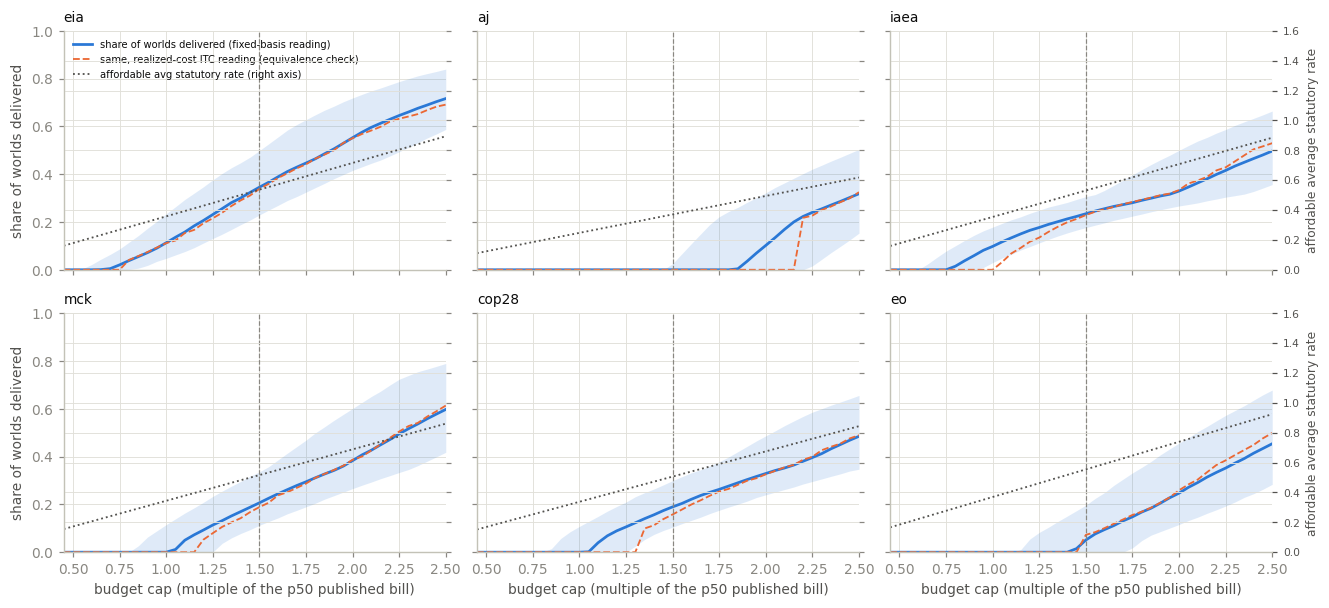

In [6]:
# ---- k02: the Fig 6a source — the budget menu -------------------------------------
stale = FIGURES / "k01_achievable_share_vs_budget.png"
if stale.exists():
    stale.unlink()  # v2 horse-race figure, retired 08-31

C_SHARE = ps.ACCENT["blue"]
C_ITCCHK = ps.ACCENT["orange"]
C_RATE = ps.MUTED
fig, axes = plt.subplots(2, 3, figsize=(ps.W1 * 1.9, 5.6), sharex=True, sharey=True)
for ax, ab in zip(axes.ravel(), SCHEDULES):
    g = s02[s02["schedule"] == ab]
    ax.fill_between(g["mult"], g["share_flat_lo"], g["share_flat_hi"],
                    color=C_SHARE, alpha=0.15, lw=0)
    ax.plot(g["mult"], g["share_flat"], color=C_SHARE, lw=1.8,
            label="share of worlds delivered (fixed-basis reading)")
    ax.plot(g["mult"], g["share_itc_hard"], color=C_ITCCHK, lw=1.2, ls="--",
            label="same, realized-cost ITC reading (equivalence check)")
    ax.axvline(1.5, color=ps.FAINT, lw=0.8, ls="--")
    ax.set_title(ab, fontsize=9, color=ps.INK)
    ax.set_ylim(0, 1)
    ax.set_xlim(MULT[0], MULT[-1])

    ax2 = ax.twinx()
    ax2.plot(g["mult"], g["menu_rate_avg_stat"], color=C_RATE, lw=1.2, ls=":",
             label="affordable avg statutory rate (right axis)")
    ax2.set_ylim(0, 1.6)
    if ab in ("iaea", "eo"):
        ax2.set_ylabel("affordable average statutory rate", fontsize=8, color=C_RATE)
        ax2.tick_params(axis="y", labelsize=7, colors=C_RATE)
    else:
        ax2.set_yticklabels([])
for ax in axes[1]:
    ax.set_xlabel("budget cap (multiple of the p50 published bill)")
for ax in axes[:, 0]:
    ax.set_ylabel("share of worlds delivered")
h1, l1 = axes[0, 0].get_legend_handles_labels()
import matplotlib.lines as mlines
h1.append(mlines.Line2D([], [], color=C_RATE, lw=1.2, ls=":"))
l1.append("affordable avg statutory rate (right axis)")
axes[0, 0].legend(h1, l1, loc="upper left", fontsize=6.5, frameon=False)
fig.tight_layout()
ps.savefig(fig, FIGURES / "k02_budget_menu.png")
plt.show()


In [7]:
# ---- s04: verdict + manifest ------------------------------------------------------
s04 = pd.DataFrame([
    dict(gate="G0", status="PASS" if G0 else "FAIL",
         detail="t08 bills reproduced for all smr100 anchors (<=0.051 $B)"),
    dict(gate="G1", status="PASS" if G1 else "FAIL",
         detail="rate interpolation exact at all 18 anchors; p50 thresholds = calibration point"),
    dict(gate="G2", status="PASS" if G2 else "FAIL",
         detail="t09 reference schedules == fed r01 headline rates; r03 bracket = (head-5, head-1]"),
    dict(gate="G3", status="PASS" if G3 else "FAIL",
         detail="outlay level calibrated to t12; post-calibration residual <= 7% at all anchors"),
    dict(gate="G4", status="PASS" if G4 else "FAIL",
         detail="monotone shares; flat closed form; hard <= quantile; exceedance <= 0.05"),
    dict(gate="G5", status="PASS" if G5 else "FAIL",
         detail="+-20% need band computed and exported (s02 lo/hi columns)"),
])
s04.to_csv(EXPORTS / "s04_verdict.csv", index=False)
print(s04.to_string(index=False))

manifest = sorted(p.name for p in EXPORTS.glob("s*.csv")) + \
           sorted(p.name for p in FIGURES.glob("k*.png"))
print("\nmanifest:")
for m in manifest:
    print(" ", m)
assert {"s01_per_world_thresholds.csv", "s02_budget_sweep.csv",
        "s03_headline_table.csv", "s04_verdict.csv",
        "k02_budget_menu.png"} <= set(manifest)
assert "k01_achievable_share_vs_budget.png" not in manifest, "stale v2 figure present"
print("\nall gates:", "PASS" if all([G0, G1, G2, G3, G4, G5]) else "FAIL")


gate status                                                                            detail
  G0   PASS                          t08 bills reproduced for all smr100 anchors (<=0.051 $B)
  G1   PASS    rate interpolation exact at all 18 anchors; p50 thresholds = calibration point
  G2   PASS t09 reference schedules == fed r01 headline rates; r03 bracket = (head-5, head-1]
  G3   PASS    outlay level calibrated to t12; post-calibration residual <= 7% at all anchors
  G4   PASS           monotone shares; flat closed form; hard <= quantile; exceedance <= 0.05
  G5   PASS                         +-20% need band computed and exported (s02 lo/hi columns)

manifest:
  s01_per_world_thresholds.csv
  s02_budget_sweep.csv
  s03_headline_table.csv
  s04_verdict.csv
  k02_budget_menu.png

all gates: PASS
